In [1]:
import cv2
import os
import numpy as np
from skimage.feature import local_binary_pattern


In [2]:
image = cv2.imread('image.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
img = local_binary_pattern(gray_image, 40, 5)
cv2.imwrite('written.jpg', img)

[ WARN:0@2.037] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


True

In [3]:
image_fft = np.fft.ifft(np.real(np.fft.fft(image)))

In [4]:
cv2.imwrite('written.jpg', np.real(image_fft))

True

In [5]:
import torch
import torch.nn.functional as F
import numpy as np

def compute_lbp(image):
    """Computes the LBP (Local Binary Pattern) of a grayscale image."""
    offsets = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),          (0, 1),
        (1, -1), (1, 0), (1, 1)
    ]

    # Convert image to tensor if it's not already
    if isinstance(image, np.ndarray):
        image = torch.tensor(image, dtype=torch.float32)

    # Ensure image is 2D
    assert image.ndim == 2, "Image must be grayscale (2D tensor)."

    padded = F.pad(image.unsqueeze(0).unsqueeze(0), (1, 1, 1, 1), mode='replicate').squeeze()

    center = padded[1:-1, 1:-1]
    lbp = torch.zeros_like(center)

    for i, (dy, dx) in enumerate(offsets):
        # neighbor = padded[1+dy:-1+dy, 1+dx:-1+dx]
        # print(i)
        neighbor = padded[1:-1, 1:-1].clone()  # Ensures correct shape
        neighbor = padded[(1 + dy):(padded.shape[0] - 1 + dy), (1 + dx):(padded.shape[1] - 1 + dx)]

        lbp += (neighbor >= center).to(torch.uint8) * (1 << i)

    return lbp


In [6]:
lbp_image = compute_lbp(gray_image)
print(lbp_image)

tensor([[ 11., 255., 255.,  ..., 255., 130., 255.],
        [107., 255.,  16.,  ..., 125., 186.,  17.],
        [104., 125.,  22.,  ...,  64., 127.,  23.],
        ...,
        [235., 253., 212.,  ..., 105., 125.,  54.],
        [251., 253., 212.,  ..., 105., 237., 255.],
        [248., 212., 212.,  ..., 105., 105., 248.]])


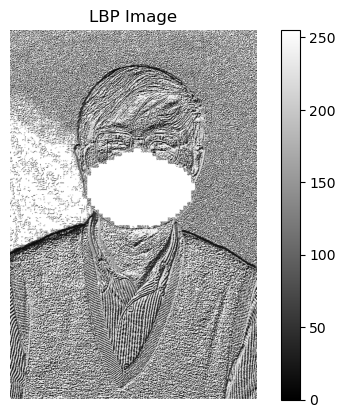

In [7]:
import matplotlib.pyplot as plt

def show_image(image, title="Image"):
    plt.imshow(image, cmap="gray")  # Display image in grayscale
    plt.colorbar()  # Show color scale
    plt.title(title)
    plt.axis("off")  # Hide axis labels
    plt.show()

show_image(lbp_image, title="LBP Image")


In [8]:
import torch
import torchvision.models as models

# Load pre-trained ResNet model
resnet = models.resnet18(pretrained=True)

# Extract convolution and pooling layer weights
conv1_weights = resnet.conv1.weight  # First convolution layer
pool_weights = resnet.maxpool  # Pooling layer

print("Conv1 Weights Shape:", conv1_weights.shape)


/share/pkg.8/academic-ml/fall-2024/install/fall-2024-pyt/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/share/pkg.8/academic-ml/fall-2024/install/fall-2024-pyt/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Conv1 Weights Shape: torch.Size([64, 3, 7, 7])


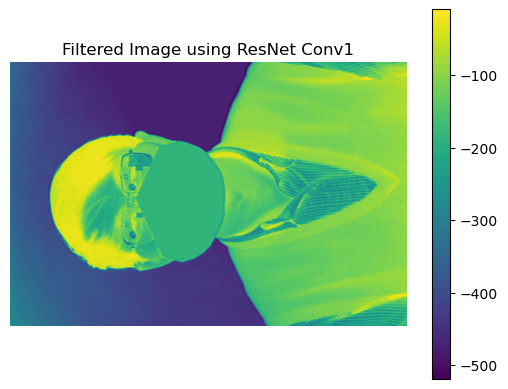

In [9]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def apply_conv_layer(image, conv_weights):
    """Applies a convolutional layer filter to an image."""
    image = image.unsqueeze(0)  # Add batch & channel dim (1,1,H,W)
    filtered_image = F.conv2d(image, conv_weights, stride=1, padding=1)
    return filtered_image.squeeze().detach().numpy()  # Remove batch/channel dim

# Example grayscale image (random)
image = torch.rand(3, 224, 224)  # Simulated grayscale image
image = cv2.imread('image.jpg').T
image = torch.tensor(image)
image = cv2.imread('image.jpg').T  # Load as grayscale
image = torch.tensor(image, dtype=torch.float32)

# Apply the first convolutional filter
filtered_image = apply_conv_layer(image, conv1_weights[62:63])  # Using one filter

# Display the filtered image
plt.imshow(filtered_image)
plt.colorbar()
plt.title("Filtered Image using ResNet Conv1")
plt.axis("off")
plt.show()


In [10]:
import torch.nn as nn
all_layers = list(resnet.children())  # Get all layers
half_layers = nn.Sequential(*all_layers[:1])  # Take half

print(half_layers)  #

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
)


In [11]:
half_layers(image.unsqueeze(0)).shape

torch.Size([1, 64, 256, 384])

In [12]:
input_tensor = half_layers(image.unsqueeze(0))

lbp_output = []
for c in range(input_tensor.shape[1]):
    lbp_output.append(compute_lbp(input_tensor[0, c, :, :]))  # Apply LBP to each channel

lbp_output = torch.stack(lbp_output)  # Stack the LBP results
print(lbp_output.shape)  # Should be [64, 128, 192]

torch.Size([64, 256, 384])


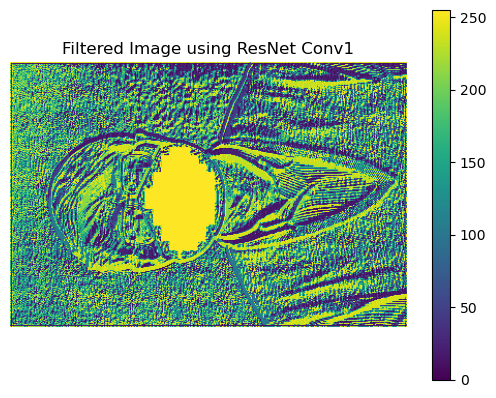

In [13]:
plt.imshow(lbp_output[61])
plt.colorbar()
plt.title("Filtered Image using ResNet Conv1")
plt.axis("off")
plt.show()

In [14]:
f = torch.fft.fft2(lbp_output)
fshift = torch.fft.fftshift(f)

In [15]:
print(fshift)

tensor([[[ 10798.0000+0.0000e+00j,  -4060.6953-6.0513e+03j,
           16015.1533+6.2800e+03j,  ...,
           14501.3633-1.9486e+03j,  16015.1533-6.2800e+03j,
           -4060.6953+6.0513e+03j],
         [ -3574.8796-1.1576e+03j,   2764.4722+4.0197e+03j,
            7892.5303-2.0936e+03j,  ...,
           13584.0801+7.7023e+03j,  -1130.9573+1.4803e+04j,
          -15916.7148-4.5772e+03j],
         [ -7019.7915+4.4270e+03j,     83.5459+1.3725e+04j,
           -5481.5015-8.7266e+02j,  ...,
            -425.8672-2.3090e+04j,  -2733.0708+1.8155e+03j,
          -19053.9766-1.9511e+04j],
         ...,
         [-10372.7246-5.0003e+03j,   9527.3340+1.2161e+04j,
          -12798.5361-2.5230e+03j,  ...,
             874.8018+9.3970e+03j,  17316.9980-1.1622e+04j,
           -3591.1548+1.1669e+04j],
         [ -7019.7930-4.4270e+03j, -19053.9746+1.9511e+04j,
           -2733.0691-1.8155e+03j,  ...,
           20316.7422+1.0105e+04j,  -5481.5049+8.7267e+02j,
              83.5518-1.3725e+04j],
 

In [16]:
rows, cols = lbp_output[58].shape
crow, ccol = rows // 2, cols // 2
mask = torch.ones((rows, cols), dtype=torch.float32)
r = 30
y, x = torch.meshgrid(torch.fft.fftfreq(rows), torch.fft.fftfreq(cols))
mask[((x - ccol) ** 2 + (y - crow) ** 2) <= r ** 2] = 0.25

# Apply mask
fshift = fshift * mask

# Inverse Fourier Transform
f_ishift = torch.fft.ifftshift(fshift)
image_back = torch.fft.ifft2(f_ishift)
image_back = image_back.abs()

# Display the result
# plt.imshow(image_back)
# plt.show()

/share/pkg.8/academic-ml/fall-2024/install/fall-2024-pyt/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [17]:
image_back.unsqueeze(0).shape

torch.Size([1, 64, 256, 384])

In [18]:
next_half_layers = nn.Sequential(*all_layers[1:-1]) 
print(next_half_layers)
fin = next_half_layers(image_back.unsqueeze(0))

Sequential(
  (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (3): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn

In [19]:
len(fin)

1

### Final Code

In [20]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torchvision.models as models
import numpy as np

def compute_lbp(image):
    """Computes the LBP (Local Binary Pattern) of a grayscale image."""
    offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    
    if isinstance(image, np.ndarray):
        image = torch.tensor(image, dtype=torch.float32)

    assert image.ndim == 2, "Image must be grayscale (2D tensor)."
    padded = F.pad(image.unsqueeze(0).unsqueeze(0), (1, 1, 1, 1), mode='replicate').squeeze()
    center = padded[1:-1, 1:-1]
    lbp = torch.zeros_like(center)

    for i, (dy, dx) in enumerate(offsets):
        neighbor = padded[(1 + dy):(padded.shape[0] - 1 + dy), (1 + dx):(padded.shape[1] - 1 + dx)]
        lbp += (neighbor >= center).to(torch.uint8) * (1 << i)

    return lbp

def apply_lbp_to_image(image, model_layers):
    """Applies LBP to the image after passing it through the first half of the ResNet model."""
    # Apply the first half of ResNet
    input_tensor = model_layers(image.unsqueeze(0))

    lbp_output = []
    for c in range(input_tensor.shape[1]):
        lbp_output.append(compute_lbp(input_tensor[0, c, :, :]))  # Apply LBP to each channel

    lbp_output = torch.stack(lbp_output)  # Stack the LBP results
    return lbp_output

def apply_frequency_filter(lbp_output):
    """Applies a frequency filter to the LBP output."""
    f = torch.fft.fft2(lbp_output)
    fshift = torch.fft.fftshift(f)

    rows, cols = lbp_output[58].shape
    crow, ccol = rows // 2, cols // 2
    mask = torch.ones((rows, cols), dtype=torch.float32)
    r = 30
    y, x = torch.meshgrid(torch.fft.fftfreq(rows), torch.fft.fftfreq(cols))
    mask[((x - ccol) ** 2 + (y - crow) ** 2) <= r ** 2] = 0.25

    # Apply mask
    fshift = fshift * mask

    # Inverse Fourier Transform
    f_ishift = torch.fft.ifftshift(fshift)
    image_back = torch.fft.ifft2(f_ishift)
    image_back = image_back.abs()

    return image_back

def apply_resnet_layers(resnet, image_back):
    """Passes the image back through the remaining layers of the ResNet model."""
    all_layers = list(resnet.children())  # Get all layers
    next_half_layers = nn.Sequential(*all_layers[1:-1])  # Get the layers excluding the first and last
    output = next_half_layers(image_back.unsqueeze(0))
    return output

def process_image(image, resnet):
    """Complete process: compute LBP, apply frequency filtering, and pass through ResNet layers."""
    # Step 1: Apply LBP to the first half of the ResNet model
    lbp_output = apply_lbp_to_image(image, nn.Sequential(*list(resnet.children())[:1]))

    # Step 2: Apply frequency filtering to the LBP output
    image_back = apply_frequency_filter(lbp_output)

    # Step 3: Pass the result through the remaining ResNet layers
    output = apply_resnet_layers(resnet, image_back)
    
    return output


In [21]:
start_layers = nn.Sequential(*all_layers[:-1])

In [29]:
# image = cv2.imread('../../colorferet/gray_mask_images/00009/00009_930831_fb_a.jpg')
image = cv2.imread('../../colorferet/images_extracted/00001/00001_930831_fa_a.ppm')
image = torch.tensor(image.T, dtype=torch.float32)
# gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

fin1 = process_image(image, resnet)
fin1_1 = start_layers(image.unsqueeze(0))

In [43]:
image = cv2.imread('../../colorferet/gray_mask_images/00009/00009_930831_fa_a.jpg')
image = torch.tensor(image.T, dtype=torch.float32)
# gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

fin2 = process_image(image, resnet)
fin2_1 = start_layers(image.unsqueeze(0))

In [44]:
result = torch.sum(fin1 * fin2, dim=1)  # Result will be of shape (32,)

In [45]:
print(result)

tensor([[[422.9515]]], grad_fn=<SumBackward1>)


In [46]:
cos_sim = torch.nn.functional.cosine_similarity(fin1, fin2, dim=1)

In [47]:
cos_sim

tensor([[[0.9992]]], grad_fn=<SumBackward1>)

In [48]:
torch.sum((fin1-fin2)**2,dim=1)

tensor([[[0.7015]]], grad_fn=<SumBackward1>)

In [36]:
torch.sum((fin1_1-fin2_1)**2,dim=1)

tensor([[[0.4317]]], grad_fn=<SumBackward1>)